In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/sushilpednekar/Documents/academic_data - academic_data.csv")

In [3]:
df.head(15)

,Firstname,Lastname,Gender,SPOS,DSBDA,WT,DA
0,LA,Roy,M,85.0,88,90.0,92
1,SA,Dixit,F,90.0,90,94.0,95
2,AB,Danial,M,NaN,na,100.0,80
3,DA,Kapoor,M,95.0,86,500.0,82
4,SA,Jha,F,NaN,84,98.0,84
5,WS,Thakur,F,87.0,NaN,97.0,86
6,DY,Kapoor,M,81.0,80,96.0,89
7,JK,Khanna,F,40.0,88,95.0,87
8,RT,Pardesi,M,10.0,96,94.0,88
9,UV,Pardesi,M,9.0,NaN,93.0,96


In [4]:
df.dtypes

Firstname        str
Lastname         str
Gender           str
SPOS         float64
DSBDA            str
WT           float64
DA               str
dtype: object

In [5]:
df.shape

(15, 7)

In [6]:
df.isnull().sum()

Firstname    0
Lastname     0
Gender       0
SPOS         2
DSBDA        6
WT           1
DA           0
dtype: int64

In [7]:
print(df['DA'].dtype)

str


In [8]:
df['DA'].head()

0    92
1    95
2    80
3    82
4    84
Name: DA, dtype: str

In [9]:
df['DA'] = pd.to_numeric(df['DA'], errors='coerce') # --> converts values into numbers

In [10]:
# error='coerce'  ---> If any value cannot be converted to a number, replace it with NaN (missing value)”

In [11]:
df['DA'] = df['DA'].fillna(df['DA'].mean())

In [12]:
df['DA'] = df['DA'].astype(float)

In [13]:
df.dtypes

Firstname        str
Lastname         str
Gender           str
SPOS         float64
DSBDA            str
WT           float64
DA           float64
dtype: object

In [14]:
df['DA']

0      92.000000
1      95.000000
2      80.000000
3      82.000000
4      84.000000
5      86.000000
6      89.000000
7      87.000000
8      88.000000
9      96.000000
10    127.071429
11    300.000000
12    100.000000
13    200.000000
14    300.000000
Name: DA, dtype: float64

In [15]:
df['DSBDA'] = pd.to_numeric(df['DSBDA'], errors='coerce')

In [16]:
df['DSBDA'] = df['DSBDA'].fillna(df['DSBDA'].mean())

In [17]:
df['DSBDA']

0     88.000
1     90.000
2     87.375
3     86.000
4     84.000
5     87.375
6     80.000
7     88.000
8     96.000
9     87.375
10    87.000
11    87.375
12    87.375
13    87.375
14    87.375
Name: DSBDA, dtype: float64

In [18]:
df.isnull().sum()

Firstname    0
Lastname     0
Gender       0
SPOS         2
DSBDA        0
WT           1
DA           0
dtype: int64

In [19]:
df['DSBDA'] = df['DSBDA'].astype(float)

In [20]:
df.dtypes

Firstname        str
Lastname         str
Gender           str
SPOS         float64
DSBDA        float64
WT           float64
DA           float64
dtype: object

In [21]:
df['SPOS'] = df['SPOS'].fillna(df['SPOS'].mean())

In [22]:
df['SPOS']

0      85.000000
1      90.000000
2     145.923077
3      95.000000
4     145.923077
5      87.000000
6      81.000000
7      40.000000
8      10.000000
9       9.000000
10    200.000000
11    300.000000
12    300.000000
13    300.000000
14    300.000000
Name: SPOS, dtype: float64

In [23]:
df['Gender']

0     M
1     F
2     M
3     M
4     F
5     F
6     M
7     F
8     M
9     M
10    F
11    F
12    F
13    F
14    F
Name: Gender, dtype: str

In [24]:
# # Detect and Fix Inconsistencies
# ## Example checks
df[(df['SPOS'] < 25) | (df['SPOS'] > 75)]

,Firstname,Lastname,Gender,SPOS,DSBDA,WT,DA
0,LA,Roy,M,85.000000,88.000,90.0,92.000000
1,SA,Dixit,F,90.000000,90.000,94.0,95.000000
2,AB,Danial,M,145.923077,87.375,100.0,80.000000
3,DA,Kapoor,M,95.000000,86.000,500.0,82.000000
4,SA,Jha,F,145.923077,84.000,98.0,84.000000
5,WS,Thakur,F,87.000000,87.375,97.0,86.000000
6,DY,Kapoor,M,81.000000,80.000,96.0,89.000000
8,RT,Pardesi,M,10.000000,96.000,94.0,88.000000
9,UV,Pardesi,M,9.000000,87.375,93.0,96.000000
10,MN,Desai,F,200.000000,87.000,NaN,127.071429


In [25]:
df['SPOS'] = df['SPOS'].clip(0, 100)

In [26]:
df['SPOS']

0      85.0
1      90.0
2     100.0
3      95.0
4     100.0
5      87.0
6      81.0
7      40.0
8      10.0
9       9.0
10    100.0
11    100.0
12    100.0
13    100.0
14    100.0
Name: SPOS, dtype: float64

In [27]:
mean_spos = df['SPOS'].mean()

df.loc[
    (df['SPOS'] < 25) |
    (df['SPOS'] > 75),
    'SPOS'
] = mean_spos


In [28]:
df['SPOS']

0     79.8
1     79.8
2     79.8
3     79.8
4     79.8
5     79.8
6     79.8
7     40.0
8     79.8
9     79.8
10    79.8
11    79.8
12    79.8
13    79.8
14    79.8
Name: SPOS, dtype: float64

In [30]:
# 2) scan all numeric variable -->  To detect outliers
Q1 = df['DA'].quantile(0.25) # → lower part of data
Q3 = df['DA'].quantile(0.75) # → upper part of data
IQR = Q3 - Q1 # Calculates Interquartile Range

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['DA'] < lower) | (df['DA'] > upper)]
print(outliers)

   Firstname Lastname Gender   SPOS   DSBDA    WT     DA
11        BC    Patel      F  300.0  87.375  88.0  300.0
13        XY    Patel      F  300.0  87.375  88.0  200.0
14        BC    Patel      F  300.0  87.375  88.0  300.0


In [31]:
# Data Transformation
df['DSBDA_log'] = np.log(df['DSBDA'])  # To Reduce Skewness

In [33]:
df[['DSBDA', 'DSBDA_log']].head()

,DSBDA,DSBDA_log
0,88.000,4.477337
1,90.000,4.499810
2,87.375,4.470209
3,86.000,4.454347
4,84.000,4.430817


In [20]:
df.describe()

,SPOS,DSBDA,WT,DA,DSBDA_log
count,13.000000,15.000000,14.000000,15.000000,15.000000
mean,145.923077,4.469560,122.071429,127.071429,1.497257
std,116.706513,0.037256,108.850967,76.277187,0.008330
min,9.000000,4.382027,88.000000,80.000000,1.477511
25%,81.000000,4.468059,88.500000,86.500000,1.496954
50%,90.000000,4.470209,94.000000,92.000000,1.497435
75%,300.000000,4.473773,96.750000,113.535714,1.498232
max,300.000000,4.564348,500.000000,300.000000,1.518276


In [26]:
df['DA_log'] = np.log(df['DA'])

In [34]:
df[['DA','DA_log']].head()

,DA,DA_log
0,92.0,4.521789
1,95.0,4.553877
2,80.0,4.382027
3,82.0,4.406719
4,84.0,4.430817


In [27]:
df.describe()

,SPOS,DSBDA,WT,DA,DA_log
count,15.000000,15.000000,14.000000,15.000000,15.000000
mean,145.923077,87.375000,122.071429,127.071429,4.726774
std,108.049236,3.271904,108.850967,76.277187,0.457698
min,9.000000,80.000000,88.000000,80.000000,4.382027
25%,83.000000,87.187500,88.500000,86.500000,4.460128
50%,95.000000,87.375000,94.000000,92.000000,4.521789
75%,250.000000,87.687500,96.750000,113.535714,4.724960
max,300.000000,96.000000,500.000000,300.000000,5.703782


In [28]:
df['DA']

0      92.000000
1      95.000000
2      80.000000
3      82.000000
4      84.000000
5      86.000000
6      89.000000
7      87.000000
8      88.000000
9      96.000000
10    127.071429
11    300.000000
12    100.000000
13    200.000000
14    300.000000
Name: DA, dtype: float64

In [31]:
df['SPOS_log'] = np.log(df['SPOS'])

In [32]:
df[['SPOS','SPOS']].head()

,SPOS,SPOS
0,79.8,79.8
1,79.8,79.8
2,79.8,79.8
3,79.8,79.8
4,79.8,79.8


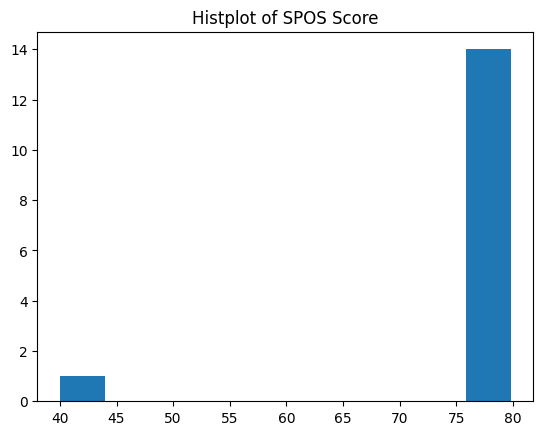

In [34]:
plt.hist(df['SPOS'])
plt.title("Histplot of SPOS Score")
plt.show()
